In [2]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from PIL import Image, ImageOps, ImageFilter
import numpy as np
import os
from PIL import ImageOps, ImageFilter


print("Baixando dados...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target

X = X[:25000]
y = y[:25000]

Baixando dados...


In [3]:
# Data augmentation + leitura de fotos rotuladas (0-9)
from pathlib import Path
import random
from PIL import ImageEnhance, ImageFilter

def preprocessar_imagem(
    caminho_arquivo,
    aplicar_inversao=True,
    auto_invert=True,
    usar_autocontrast=False,
    usar_filtro=True,
    limiar=30,
    tamanho_alvo=28,
    tamanho_digito=20,
    ):
    img = Image.open(caminho_arquivo).convert('L')
    img_original = img.copy()

    if usar_autocontrast:
        img = ImageOps.autocontrast(img)

    if auto_invert:
        if np.array(img).mean() > 127:
            img = ImageOps.invert(img)
    elif aplicar_inversao:
        img = ImageOps.invert(img)

    if usar_filtro:
        img = img.filter(ImageFilter.MedianFilter(size=3))

    arr = np.array(img)
    ys, xs = np.where(arr > limiar)
    if len(xs) > 0 and len(ys) > 0:
        bbox = (xs.min(), ys.min(), xs.max() + 1, ys.max() + 1)
        img = img.crop(bbox)

    w, h = img.size
    escala = float(tamanho_digito) / max(w, h)
    novo_w, novo_h = max(1, int(w * escala)), max(1, int(h * escala))
    img = img.resize((novo_w, novo_h), Image.LANCZOS)
    canvas = Image.new('L', (tamanho_alvo, tamanho_alvo), 0)
    offset = ((tamanho_alvo - novo_w) // 2, (tamanho_alvo - novo_h) // 2)
    canvas.paste(img, offset)
    return img_original, canvas

def aplicar_shift(img_proc, dx, dy):
    return (
        ImageOps.expand(img_proc, border=2, fill=0)
        .crop((2 + dx, 2 + dy, 30 + dx, 30 + dy))
    )

def gerar_variantes(
    img_proc,
    n_augment=8,
    rot_range=12,
    shift=2,
    contrast_range=(0.8, 1.2),
    thickness_modes=("orig", "thick", "thin"),
    ):
    variantes = []
    for _ in range(n_augment):
        img = img_proc
        ang = random.uniform(-rot_range, rot_range)
        img = img.rotate(ang, fillcolor=0)
        dx = random.randint(-shift, shift)
        dy = random.randint(-shift, shift)
        img = aplicar_shift(img, dx, dy)
        mode = random.choice(thickness_modes)
        if mode == "thick":
            img = img.filter(ImageFilter.MaxFilter(size=3))
        elif mode == "thin":
            img = img.filter(ImageFilter.MinFilter(size=3))
        c = random.uniform(*contrast_range)
        img = ImageEnhance.Contrast(img).enhance(c)
        variantes.append(img)
    return variantes

def carregar_dataset_personalizado(
    root_dir,
    max_por_classe=None,
    augmentar=True,
    n_augment=8,
    incluir_original=True,
    seed=42,
    ):
    X_list, y_list = [], []
    root = Path(root_dir)
    if seed is not None:
        random.seed(seed)
    subdirs = sorted([p for p in root.iterdir() if p.is_dir()])
    print(f"Pastas encontradas: {[p.name for p in subdirs]}")
    for classe_dir in subdirs:
        label = classe_dir.name
        arquivos = list(classe_dir.glob("*"))
        print(f"  Classe '{label}': {len(arquivos)} arquivos")
        if max_por_classe:
            random.shuffle(arquivos)
            arquivos = arquivos[:max_por_classe]
        erros = 0
        for caminho in arquivos:
            try:
                _, img_proc = preprocessar_imagem(str(caminho))
            except Exception as e:
                erros += 1
                if erros <= 2:
                    print(f"    ERRO em {caminho.name}: {e}")
                continue
            imgs = []
            if incluir_original:
                imgs.append(img_proc)
            if augmentar:
                imgs = imgs + gerar_variantes(img_proc, n_augment=n_augment)
            for img in imgs:
                X_list.append(np.array(img).reshape(-1))
                y_list.append(label)
        ok = len(arquivos) - erros
        print(f"    -> {ok} carregadas, {erros} erros")
    return np.array(X_list), np.array(y_list)


In [4]:
from sklearn.pipeline import Pipeline

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Treinando o modelo...")
log_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000))
    ]
 )
rf_clf = RandomForestClassifier(n_estimators=200, random_state=42)
svm_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(gamma='scale'))
    ]
 )

voting_clf = VotingClassifier(
    estimators=[('lr', log_clf), ('rf', rf_clf), ('svc', svm_clf)],
    voting='hard'
    )

voting_clf.fit(X_train, y_train)


Treinando o modelo...


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('rf', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'hard'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0


In [5]:
# Carregar fotos personalizadas e retreinar misturando com MNIST
custom_root = "/home/raf75/sexto-periodo/machine/fotos"
X_custom, y_custom = carregar_dataset_personalizado(
    custom_root,
    max_por_classe=200,
    augmentar=True,
    n_augment=6,
)
print(X_custom.shape, y_custom.shape)

X_mix = np.vstack([X_train, X_custom])
y_mix = np.concatenate([y_train, y_custom])
voting_clf.fit(X_mix, y_mix)
print("Retreino concluido!")


Pastas encontradas: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
  Classe '0': 17 arquivos
    -> 17 carregadas, 0 erros
  Classe '1': 6 arquivos
    -> 6 carregadas, 0 erros
  Classe '2': 20 arquivos
    -> 20 carregadas, 0 erros
  Classe '3': 16 arquivos
    -> 16 carregadas, 0 erros
  Classe '4': 8 arquivos
    -> 8 carregadas, 0 erros
  Classe '5': 11 arquivos
    -> 11 carregadas, 0 erros
  Classe '6': 7 arquivos
    -> 7 carregadas, 0 erros
  Classe '7': 17 arquivos
    -> 17 carregadas, 0 erros
  Classe '8': 9 arquivos
    -> 9 carregadas, 0 erros
  Classe '9': 10 arquivos
    -> 10 carregadas, 0 erros
(847, 784) (847,)
Retreino concluido!



Resultado da predicao: 8
Media original: 239.88 | Media processada: 26.57


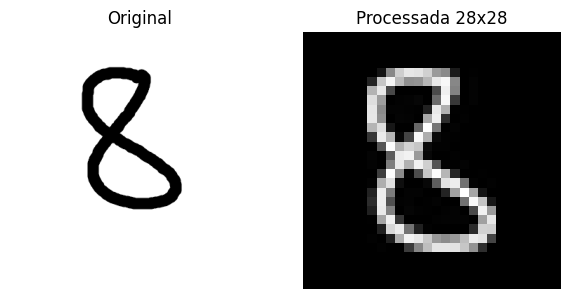

In [6]:
import matplotlib.pyplot as plt
from PIL import Image, ImageOps, ImageFilter
import os

def preprocessar_imagem(
    caminho_arquivo,
    aplicar_inversao=True,
    auto_invert=True,
    usar_autocontrast=False,
    usar_filtro=True,
    limiar=30,
    tamanho_alvo=28,
    tamanho_digito=20,
    ):
    img = Image.open(caminho_arquivo).convert('L')
    img_original = img.copy()
    
    if usar_autocontrast:
        img = ImageOps.autocontrast(img)
    
    if auto_invert:
        if np.array(img).mean() > 127:
            img = ImageOps.invert(img)
    elif aplicar_inversao:
        img = ImageOps.invert(img)
    
    if usar_filtro:
        img = img.filter(ImageFilter.MedianFilter(size=3))
    
    arr = np.array(img)
    ys, xs = np.where(arr > limiar)
    if len(xs) > 0 and len(ys) > 0:
        bbox = (xs.min(), ys.min(), xs.max() + 1, ys.max() + 1)
        img = img.crop(bbox)
    
    w, h = img.size
    escala = float(tamanho_digito) / max(w, h)
    novo_w, novo_h = max(1, int(w * escala)), max(1, int(h * escala))
    img = img.resize((novo_w, novo_h), Image.LANCZOS)
    canvas = Image.new('L', (tamanho_alvo, tamanho_alvo), 0)
    offset = ((tamanho_alvo - novo_w) // 2, (tamanho_alvo - novo_h) // 2)
    canvas.paste(img, offset)
    return img_original, canvas

def prever_digito(caminho_arquivo, modelo, aplicar_inversao=True):
    img_original, img_proc = preprocessar_imagem(
        caminho_arquivo,
        aplicar_inversao=aplicar_inversao,
        auto_invert=True,
        usar_autocontrast=False,
        usar_filtro=True,
        limiar=30,
    )
    img_array = np.array(img_proc).reshape(1, -1)
    return modelo.predict(img_array)[0], img_original, img_proc

diretorio = '/home/raf75/sexto-periodo/machine/fotos'
nome_arquivo = '8_vermelho.png'
caminho_completo = os.path.join(diretorio, nome_arquivo)

aplicar_inversao = True

try:
    resultado, img_orig, img_proc = prever_digito(
        caminho_completo,
        voting_clf,
        aplicar_inversao=aplicar_inversao,
    )
    print(f"\nResultado da predicao: {resultado}")
    print(f"Media original: {np.array(img_orig).mean():.2f} | Media processada: {np.array(img_proc).mean():.2f}")
    
    plt.figure(figsize=(6, 3))
    plt.subplot(1, 2, 1)
    plt.title('Original')
    plt.imshow(img_orig, cmap='gray')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.title('Processada 28x28')
    plt.imshow(img_proc, cmap='gray')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
except FileNotFoundError:
    print(f"\nErro: O arquivo {caminho_completo} nao foi encontrado.")

In [8]:
import tkinter as tk
from PIL import Image, ImageDraw

def abrir_paint(modelo):
    CANVAS_SIZE = 280
    BRUSH = 14

    root = tk.Tk()
    root.title("Paint - Reconhecimento de Dígitos")
    root.resizable(False, False)

    pil_img = Image.new("L", (CANVAS_SIZE, CANVAS_SIZE), 0)
    draw_ctx = ImageDraw.Draw(pil_img)

    label_resultado = tk.Label(
        root,
        text="Desenhe um número e clique em Reconhecer",
        font=("Arial", 13),
        pady=6,
    )
    label_resultado.pack()

    canvas = tk.Canvas(
        root, width=CANVAS_SIZE, height=CANVAS_SIZE, bg="black", cursor="crosshair"
    )
    canvas.pack(padx=10)

    def desenhar(event):
        x, y = event.x, event.y
        canvas.create_oval(
            x - BRUSH, y - BRUSH, x + BRUSH, y + BRUSH, fill="white", outline="white"
        )
        draw_ctx.ellipse([x - BRUSH, y - BRUSH, x + BRUSH, y + BRUSH], fill=255)

    canvas.bind("<B1-Motion>", desenhar)
    canvas.bind("<Button-1>", desenhar)

    def reconhecer():
        img_28 = pil_img.resize((28, 28), Image.LANCZOS)
        arr = np.array(img_28).reshape(1, -1).astype(float)
        pred = modelo.predict(arr)[0]
        label_resultado.config(
            text=f"Número reconhecido: {pred}",
            fg="green",
            font=("Arial", 18, "bold"),
        )

    def limpar():
        canvas.delete("all")
        draw_ctx.rectangle([0, 0, CANVAS_SIZE, CANVAS_SIZE], fill=0)
        label_resultado.config(
            text="Desenhe um número e clique em Reconhecer",
            fg="black",
            font=("Arial", 13),
        )

    frame_btn = tk.Frame(root)
    frame_btn.pack(pady=8)
    tk.Button(
        frame_btn,
        text="Reconhecer",
        command=reconhecer,
        bg="#28a745",
        fg="white",
        font=("Arial", 12, "bold"),
        padx=12,
        pady=4,
    ).pack(side=tk.LEFT, padx=8)
    tk.Button(
        frame_btn,
        text="Limpar",
        command=limpar,
        bg="#dc3545",
        fg="white",
        font=("Arial", 12),
        padx=12,
        pady=4,
    ).pack(side=tk.LEFT, padx=8)

    root.mainloop()


abrir_paint(voting_clf)
